In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from pathlib import Path
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

In [2]:
class MushroomVisualizer:
    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
        self.classes = ['edible', 'conditionally_edible', 'poisonous', 'deadly']
        self.class_colors = {
            'edible': 'green',
            'conditionally_edible': 'orange',
            'poisonous': 'red',
            'deadly': 'darkred'
        }
 
    def explore_dataset_structure(self):
        print("*****   EDA   *****")        

        # check if the path exists
        if not self.dataset_path.exists():
            print(f"Error: Dataset path '{self.dataset_path}' does not exist!")
            print(f"Current working directory: {os.getcwd()}")
            print(f"Trying to list contents of current directory...")
            
            # try exception error
            try:
                items = list(Path('.').iterdir())
                print(f"\nItems in current directory ({len(items)}):")
                
                for item in items[:20]:  # Show first 20 items
                    print(f"  {item.name}{'/' if item.is_dir() else ''}")
                if len(items) > 20:
                    print(f"  ... and {len(items) - 20} more")
            except Exception as e:
                print(f"Error listing directory: {e}")
            return None
        
        # top-level directories
        print(f"\nRoot directory: {self.dataset_path}")
        
        # find all image files
        image_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG', '.bmp', '.BMP', '.tiff', '.TIFF']
        all_images = []
        
        for ext in image_extensions:
            all_images.extend(list(self.dataset_path.rglob(f"*{ext}")))
        
        print(f"\nTotal image files found: {len(all_images)}")
        
        if len(all_images) == 0:
            print("\n *****   No images found with standard extensions.   *****")
            
            # find any image files
            for item in self.dataset_path.rglob('*'):
                if item.is_file():
                    try:
                        with Image.open(item) as img:
                            # If we can open it as an image, add it
                            all_images.append(item)
                    except:
                        pass
            
            print(f"Found {len(all_images)} images using PIL detection")
        
        # group images by potential class based on folder names
        class_images = {cls: [] for cls in self.classes}

        # classify images based on folder names or filenames
        for img_path in all_images:
            img_str = str(img_path).lower()
            path_parts = img_str.split(os.sep)
            
            # Classify based on folder names
            assigned = False
            for cls in self.classes:
                if cls in img_str:
                    # Check if it's not a partial match (e.g., "conditionally" should match "conditionally_edible")
                    if cls == 'edible' and 'conditionally_edible' in img_str:
                        continue  # Skip, it's conditionally_edible, not just edible
                    class_images[cls].append(img_path)
                    assigned = True
                    break
            
            # check filename if not assigned
            if not assigned:
                filename = img_path.stem.lower()
                if any(word in filename for word in ['edible', 'safe', 'good', 'eatable']):
                    class_images['edible'].append(img_path)
                elif any(word in filename for word in ['condition', 'partial', 'maybe', 'cooked', 'boiled']):
                    class_images['conditionally_edible'].append(img_path)
                elif any(word in filename for word in ['poison', 'toxic', 'danger', 'toxic', 'inedible']):
                    class_images['poisonous'].append(img_path)
                elif any(word in filename for word in ['deadly', 'fatal', 'lethal', 'death', 'dead']):
                    class_images['deadly'].append(img_path)
                else:
                    # Unclassified
                    pass

        # some statistics
        print("*****   IMAGE COUNT BY CLASS (estimated):   *****")

        total_classified = 0
        for cls in self.classes:
            count = len(class_images[cls])
            total_classified += count
            print(f"{cls:25s}: {count:4d} images")
        
        unclassified = len(all_images) - total_classified
        if unclassified > 0:
            print(f"{'unclassified':25s}: {unclassified:4d} images")
        print("-" * 40)
        
        # if we found unclassified images, show some samples
        if unclassified > 0:
            print(f"\n Found {unclassified} unclassified images.")
            print("Showing folder structure to help with classification:")
            self._show_folder_structure()
        
        return class_images

    # folder structure to help understand dataset organization
    def _show_folder_structure(self, max_depth=3):
        """Show folder structure to help understand dataset organization"""
        print("\nFolder structure (max depth {}):".format(max_depth))
        print("-" * 40)
        
        def print_tree(path, depth=0):
            if depth > max_depth:
                return
                
            indent = "  " * depth
            path_obj = Path(path)
            
            # Print current directory
            print(f"{indent}{path_obj.name}/")
            
            # List directories first
            try:
                items = list(path_obj.iterdir())
                dirs = [d for d in items if d.is_dir()]
                files = [f for f in items if f.is_file()]
                
                # Print subdirectories
                for d in sorted(dirs):
                    print_tree(d, depth + 1)
                
                # Print files (limited)
                if files and depth < max_depth:
                    file_indent = "  " * (depth + 1)
                    for f in sorted(files)[:5]:  # Show only first 5 files
                        print(f"{file_indent}{f.name}")
                    if len(files) > 5:
                        print(f"{file_indent}... and {len(files)-5} more files")
                        
            except PermissionError:
                print(f"{indent}  [Permission denied]")
            except Exception as e:
                print(f"{indent}  [Error: {e}]")
        
        print_tree(self.dataset_path)

    # show sample images from each class
    # class_images - dictionary w/ class as key + list of image paths as value
    # num_samples - # of samples to show each class
    def display_sample_images(self, class_images, num_samples=4):

        print("*****   SAMPLE IMAGES FROM EACH CLASSIFICATION   *****")
        
        # take out empty classes
        non_empty_classes = [cls for cls in self.classes if class_images.get(cls)]
        
        if not non_empty_classes:
            print("*****   No classified images found!   *****")
            return
        
        # create figure
        fig, axes = plt.subplots(len(non_empty_classes), num_samples + 1, 
                                figsize=(4 * (num_samples + 1), 3 * len(non_empty_classes)))
        
        if len(non_empty_classes) == 1:
            axes = axes.reshape(1, -1)
        
        for row_idx, cls in enumerate(non_empty_classes):
            images = class_images.get(cls, [])
            
            print(f"\n*****   Class: {cls} - Found {len(images)} images   *****")
            
            # select random samples
            if len(images) >= num_samples:
                sample_images = random.sample(images, num_samples)
            else:
                sample_images = images
                if len(images) > 0:
                    print(f"*****   (Only {len(images)} images available, showing all)   *****")
            
            # show class name in first column
            axes[row_idx, 0].text(0.5, 0.5, cls.upper(), 
                                 fontsize=16, fontweight='bold',
                                 color=self.class_colors.get(cls, 'black'),
                                 horizontalalignment='center',
                                 verticalalignment='center',
                                 transform=axes[row_idx, 0].transAxes)
            axes[row_idx, 0].axis('off')
            
            # show sample images
            for col_idx, img_path in enumerate(sample_images, 1):
                try:
                    # Load and display image
                    img = Image.open(img_path)
                    
                    # convert to RGB if necessary
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    # resize if too large
                    max_size = 300
                    if max(img.size) > max_size:
                        ratio = max_size / max(img.size)
                        new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
                        img = img.resize(new_size, Image.Resampling.LANCZOS)
                    
                    axes[row_idx, col_idx].imshow(img)
                    
                    # cut filename if too long
                    filename = img_path.name
                    if len(filename) > 20:
                        filename = filename[:17] + "..."
                    
                    axes[row_idx, col_idx].set_title(f"{filename}\n{img.size[0]}x{img.size[1]}", fontsize=9)
                    
                    # color-coded border
                    border_color = self.class_colors.get(cls, 'gray')
                    for spine in axes[row_idx, col_idx].spines.values():
                        spine.set_edgecolor(border_color)
                        spine.set_linewidth(3)
                    
                    axes[row_idx, col_idx].axis('off')
                    
                    # show image info.
                    print(f"   Image {col_idx}: {img_path.name} ({img.size[0]}x{img.size[1]}, {img.mode})")
                    
                except Exception as e:
                    print(f"   Error loading {img_path.name}: {str(e)}")
                    axes[row_idx, col_idx].text(0.5, 0.5, "Error\nloading\nimage",
                                               horizontalalignment='center',
                                               verticalalignment='center',
                                               fontsize=10)
                    axes[row_idx, col_idx].axis('off')
            
            # hide empty subplots
            for col_idx in range(len(sample_images) + 1, num_samples + 1):
                axes[row_idx, col_idx].axis('off')
        
        plt.suptitle("Mushroom Dataset - Sample Images by Classification", 
                    fontsize=18, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('mushroom_samples.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        return fig

    # this function is to display a grid of images from all classes
    # class_images - dictionary w/ class as key + list of image paths as value
    # images_per_class - # of images to display each class
    # grid_cols -  # of columns in the grid
    def display_image_grid(self, class_images, images_per_class=8, grid_cols=4):

        print("*****   IMAGE GRID - ALL CLASSES   *****")

        
        # filter out empty classes
        non_empty_classes = [cls for cls in self.classes if class_images.get(cls)]
        
        if not non_empty_classes:
            print("*****   No classified images found!   *****")
            return
        
        # compute grid dimensions
        grid_rows = len(non_empty_classes)
        
        fig, axes = plt.subplots(grid_rows, grid_cols, 
                                figsize=(4 * grid_cols, 3 * grid_rows))
        
        if grid_rows == 1:
            axes = axes.reshape(1, -1)
        
        for row_idx, cls in enumerate(non_empty_classes):
            images = class_images.get(cls, [])
            
            # get random images
            if len(images) >= images_per_class:
                selected_images = random.sample(images, images_per_class)
            else:
                selected_images = images
            
            for col_idx in range(grid_cols):
                if col_idx < len(selected_images):
                    img_path = selected_images[col_idx]
                    try:
                        img = Image.open(img_path)
                        if img.mode != 'RGB':
                            img = img.convert('RGB')
                        
                        # resize if too large
                        max_size = 200
                        if max(img.size) > max_size:
                            ratio = max_size / max(img.size)
                            new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
                            img = img.resize(new_size, Image.Resampling.LANCZOS)
                        
                        axes[row_idx, col_idx].imshow(img)
                        
                        # truncate filename
                        filename = img_path.stem
                        if len(filename) > 10:
                            filename = filename[:8] + ".."
                        
                        axes[row_idx, col_idx].set_title(f"{cls[:10]}\n{filename}", 
                                                       fontsize=9, color=self.class_colors.get(cls, 'black'))
                        
                        # add colored border
                        border_color = self.class_colors.get(cls, 'gray')
                        for spine in axes[row_idx, col_idx].spines.values():
                            spine.set_edgecolor(border_color)
                            spine.set_linewidth(2)
                        
                    except Exception as e:
                        axes[row_idx, col_idx].text(0.5, 0.5, "Error", 
                                                   horizontalalignment='center',
                                                   verticalalignment='center',
                                                   fontsize=10)
                else:
                    # Fill empty spots with class name
                    if col_idx == 0:
                        axes[row_idx, col_idx].text(0.5, 0.5, cls.upper(),
                                                   fontsize=12, fontweight='bold',
                                                   color=self.class_colors.get(cls, 'black'),
                                                   horizontalalignment='center',
                                                   verticalalignment='center')
                
                axes[row_idx, col_idx].axis('off')
        
        plt.suptitle("Mushroom Classification Dataset Overview", 
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('mushroom_grid.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # display results - statistics about the images
    # class_images: dictionary w/ class as key + list of image paths as value
    def analyze_image_statistics(self, class_images):

        print("\n *****   IMAGE STATISTICS ANALYSIS   *****")
        
        stats = {
            'class_name': [],
            'count': [],
            'avg_width': [],
            'avg_height': [],
            'min_width': [],
            'max_width': [],
            'min_height': [],
            'max_height': [],
            'aspect_ratios': []
        }
        
        all_aspect_ratios = []
        all_resolutions = []
        
        for cls in self.classes:
            images = class_images.get(cls, [])
            if not images:
                continue
            
            widths = []
            heights = []
            aspect_ratios_cls = []
            
            for img_path in images:
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        widths.append(width)
                        heights.append(height)
                        aspect_ratio = width / height
                        aspect_ratios_cls.append(aspect_ratio)
                        all_aspect_ratios.append(aspect_ratio)
                        all_resolutions.append((width, height))
                except Exception as e:
                    print(f"Warning: Could not read {img_path.name}: {e}")
                    continue

             # add if only successfully read some images
            if widths: 
                stats['class_name'].append(cls)
                stats['count'].append(len(images))
                stats['avg_width'].append(np.mean(widths))
                stats['avg_height'].append(np.mean(heights))
                stats['min_width'].append(np.min(widths))
                stats['max_width'].append(np.max(widths))
                stats['min_height'].append(np.min(heights))
                stats['max_height'].append(np.max(heights))
                stats['aspect_ratios'].append(aspect_ratios_cls)
        
        # no data collected
        if not stats['class_name']: 
            print("*****   No image data could be read for statistics.   *****")
            return None
        
        # create DataFrame
        df_stats = pd.DataFrame(stats)
        
        # print statistics results
        print("\n *****   CLASS STATISTICS:   *****")
 
        for idx, row in df_stats.iterrows():
            cls_name = row['class_name']
            print(f"\n{cls_name:25s}:")
            print(f"  Count: {row['count']:4d} images")
            print(f"  Average size: {row['avg_width']:.0f} x {row['avg_height']:.0f}")
            print(f"  Min size: {row['min_width']:.0f} x {row['min_height']:.0f}")
            print(f"  Max size: {row['max_width']:.0f} x {row['max_height']:.0f}")
        
        # create visualizations
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # bar charts of image count
        axes[0, 0].bar(df_stats['class_name'], df_stats['count'], 
                      color=[self.class_colors.get(cls, 'gray') for cls in df_stats['class_name']])
        axes[0, 0].set_title('Number of Images per Class', fontweight='bold')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # show values of the plot
        for i, v in enumerate(df_stats['count']):
            axes[0, 0].text(i, v + max(df_stats['count']) * 0.01, str(v), 
                           ha='center', va='bottom', fontsize=9)
        
        # average image sizes
        bar_width = 0.35
        x = np.arange(len(df_stats))
        axes[0, 1].bar(x - bar_width/2, df_stats['avg_width'], bar_width, 
                      label='Width', color='skyblue')
        axes[0, 1].bar(x + bar_width/2, df_stats['avg_height'], bar_width, 
                      label='Height', color='lightcoral')
        axes[0, 1].set_title('Average Image Dimensions', fontweight='bold')
        axes[0, 1].set_ylabel('Pixels')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(df_stats['class_name'], rotation=45)
        axes[0, 1].legend()
        
        # aspect ratio distribution - FIXED VERSION
        aspect_ratio_data = []
        class_labels = []
        for i, cls in enumerate(df_stats['class_name']):
            aspect_ratio_data.extend(df_stats.loc[i, 'aspect_ratios'])
            class_labels.extend([cls] * len(df_stats.loc[i, 'aspect_ratios']))
        
        if aspect_ratio_data:  # Check if we have data
            aspect_df = pd.DataFrame({'class': class_labels, 'aspect_ratio': aspect_ratio_data})
            
            # FIXED: Added hue='class' and legend=False
            sns.boxplot(data=aspect_df, x='class', y='aspect_ratio', hue='class',
                       ax=axes[1, 0], palette=self.class_colors, legend=False)
            
            axes[1, 0].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Square (1:1)')
            axes[1, 0].set_title('Aspect Ratio Distribution', fontweight='bold')
            axes[1, 0].set_ylabel('Width / Height Ratio')
            axes[1, 0].set_xlabel('')
            axes[1, 0].tick_params(axis='x', rotation=45)
            axes[1, 0].legend()
        else:
            axes[1, 0].text(0.5, 0.5, 'No aspect ratio data', 
                           ha='center', va='center', fontsize=12)
            axes[1, 0].axis('off')
        
        # resolution scatter plot
        resolutions_by_class = {}
        for i, cls in enumerate(df_stats['class_name']):
            resolutions = []
            for img_path in class_images.get(cls, []):
                try:
                    with Image.open(img_path) as img:
                        resolutions.append(img.size)
                except:
                    continue
            if resolutions:
                resolutions_by_class[cls] = resolutions
        
        if resolutions_by_class:
            for cls, resolutions in resolutions_by_class.items():
                if resolutions:
                    widths, heights = zip(*resolutions)
                    axes[1, 1].scatter(widths, heights, alpha=0.6, label=cls,
                                      color=self.class_colors.get(cls, 'gray'), s=30)
            
            axes[1, 1].set_title('Image Resolutions Scatter Plot', fontweight='bold')
            axes[1, 1].set_xlabel('Width (pixels)')
            axes[1, 1].set_ylabel('Height (pixels)')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
        else:
            axes[1, 1].text(0.5, 0.5, 'No resolution data', 
                           ha='center', va='center', fontsize=12)
            axes[1, 1].axis('off')
        
        plt.suptitle('Mushroom Dataset - Comprehensive Analysis', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('mushroom_statistics.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        return df_stats
    
        # show bigger versions of sample images with detailed info...
        # class_images - dict w/ class as key + list of paths as value
        # num_samples - # of samples to show each class
        def display_large_samples(self, class_images, num_samples=3):

            print("\n *****   DETAILED IMAGE SAMPLES   *****")
        
        for cls in self.classes:
            images = class_images.get(cls, [])
            if not images:
                print(f"\n !!!!!   No images found for class: {cls}   !!!!!")
                continue
            
            # Select samples
            if len(images) >= num_samples:
                samples = random.sample(images, num_samples)
            else:
                samples = images
            
            print(f"CLASS: {cls.upper()}")
            
            # create figure for this class
            fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
            if len(samples) == 1:
                axes = [axes]
            
            for idx, (img_path, ax) in enumerate(zip(samples, axes)):
                try:
                    # load image
                    img = Image.open(img_path)
                    
                    # convert to RGB if needed
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    # show image
                    ax.imshow(img)
                    
                    # get image info
                    file_size = os.path.getsize(img_path) / 1024  # KB
                    img_info = f"{img_path.name}\n"
                    img_info += f"Size: {img.size[0]} × {img.size[1]}\n"
                    img_info += f"Mode: {img.mode}\n"
                    img_info += f"Filesize: {file_size:.1f} KB\n"
                    img_info += f"Path: {os.path.relpath(img_path, self.dataset_path)}"
                    
                    ax.set_title(img_info, fontsize=9)
                    
                    # color-coded border
                    border_color = self.class_colors.get(cls, 'gray')
                    for spine in ax.spines.values():
                        spine.set_edgecolor(border_color)
                        spine.set_linewidth(4)
                    
                    ax.axis('off')
                    
                except Exception as e:
                    ax.text(0.5, 0.5, f"Error loading image:\n{str(e)}", 
                           horizontalalignment='center', verticalalignment='center',
                           fontsize=10)
                    ax.axis('off')
            
            plt.suptitle(f"Mushroom Class: {cls.upper()}", fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            # print more info
            print(f"Class Color: {self.class_colors.get(cls, 'N/A')}")
            print(f"Total images in class: {len(images)}")
            print(f"Sample images shown: {len(samples)}")

            
    # comprehesive summary report
    # class_images - dictionary w/ class as key + list of image paths as value
    def create_summary_report(self, class_images):

        print("\n *****   DATASET SUMMARY REPORT   *****")

        total_images = sum(len(images) for images in class_images.values())
        print(f"\n *****   TOTAL IMAGES: {total_images}   *****")
        
        if total_images == 0:
            print("\n ***** No images found in the dataset!   *****")
            return 0
        
        # show class distribution
        print("\n *****   CLASS DISTRIBUTION:   *****")

        for cls in self.classes:
            count = len(class_images.get(cls, []))
            if total_images > 0:
                percentage = (count / total_images * 100)
            else:
                percentage = 0
            color_block = "█" * int(percentage / 5)  # Visual bar
            print(f"{cls:25s}: {count:4d} images ({percentage:5.1f}%) {color_block}")
        
        # check for possible potential issues
        print("\n *****   POTENTIAL ISSUES:   *****")
        
        issues_found = False
        
        # look for empty classes
        for cls in self.classes:
            if len(class_images.get(cls, [])) == 0:
                print(f"\n *****   No images found for class: {cls}   *****")
                issues_found = True
        
        # check for class imbalance
        counts = [len(class_images.get(cls, [])) for cls in self.classes]
        non_zero_counts = [c for c in counts if c > 0]
        
        if non_zero_counts and len(non_zero_counts) > 1:
            imbalance_ratio = max(non_zero_counts) / min(non_zero_counts)
            if imbalance_ratio > 3:
                print(f"\n *****  Significant class imbalance detected (ratio: {imbalance_ratio:.1f})   *****")
                issues_found = True
        
        # Check image formats
        print("\n *****   IMAGE FORMATS:   *****")

        formats = {}
        for cls, images in class_images.items():
            for img_path in images:
                ext = img_path.suffix.lower()
                formats[ext] = formats.get(ext, 0) + 1
        
        if formats:
            for fmt, count in sorted(formats.items()):
                percentage = (count / total_images * 100)
                print(f"{fmt:10s}: {count:4d} images ({percentage:5.1f}%)")
        else:
            print("No image format information available")
        
        if not issues_found:
            print("\nNo major issues detected in the dataset structure.")
        
        return total_images

MUSHROOM DATASET EDA

Found dataset at: .
Error in main visualization: cannot unpack non-iterable NoneType object

Trying quick visualization instead...
QUICK DATASET VISUALIZATION
Loading dataset...
*****   EDA   *****

Root directory: .

Total image files found: 102716
*****   IMAGE COUNT BY CLASS (estimated):   *****
edible                   : 18417 images
conditionally_edible     : 61968 images
poisonous                : 21138 images
deadly                   : 1190 images
unclassified             :    3 images
----------------------------------------

 Found 3 unclassified images.
Showing folder structure to help with classification:

Folder structure (max depth 3):
----------------------------------------
/
  .ipynb_checkpoints/
    Untitled-checkpoint.ipynb
    mushroomEDA - detailed-checkpoint.ipynb
    mushroomEDA-checkpoint.ipynb
  mushroom_dataset/
    Classes/
      .ipynb_checkpoints/
      conditionally_edible/
      deadly/
      edible/
      poisonous/
      .DS_Store
 

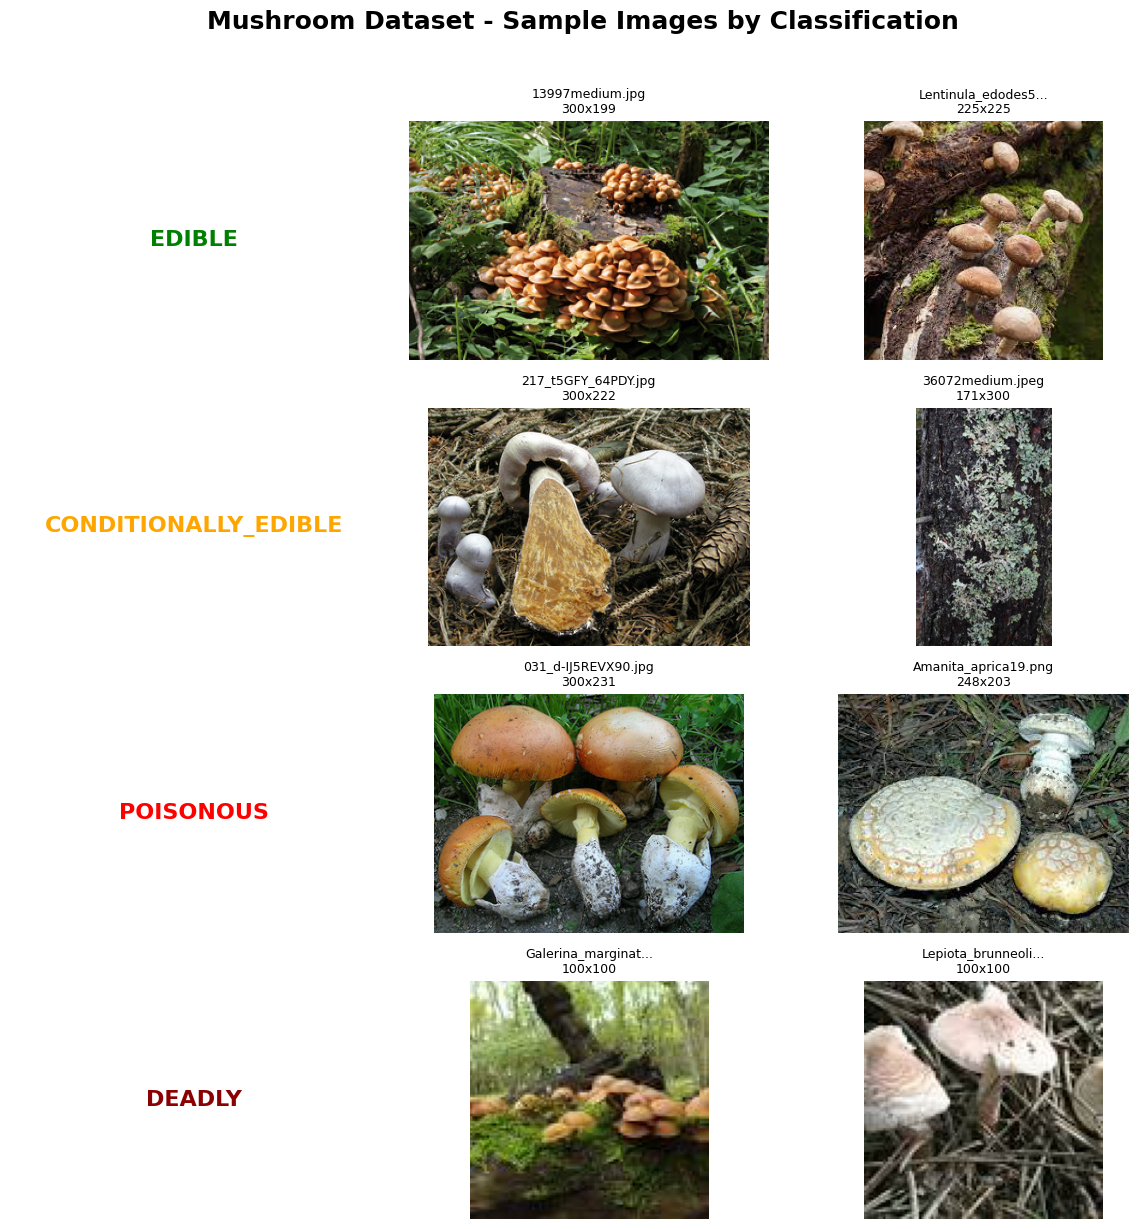


Found 102713 classified images.


In [5]:
# Main Function

def main():
    
    print("MUSHROOM DATASET EDA")
    
    # initialize the visualizer
    # replace with your actual dataset path
    
    # Start with current directory
    dataset_path = "."  
    
    # find the dataset
    possible_paths = [
        "mushroom-classification-dataset",
        "dataset",
        "data",
        "mushroom_data",
        "mushrooms",
        "."
    ]
    
    visualizer = None
    for path in possible_paths:
        if Path(path).exists():
            dataset_path = path
            print(f"\nFound dataset at: {dataset_path}")
            visualizer = MushroomVisualizer(dataset_path)
            break
    
    if visualizer is None:
        print("\nCould not find dataset. Using current directory...")
        visualizer = MushroomVisualizer(".")
    


# Alternative: Quick visualization for immediate results
def quick_visualize(dataset_path="."):

    print("QUICK DATASET VISUALIZATION")
    
    visualizer = MushroomVisualizer(dataset_path)
    
    # Get class images
    print("Loading dataset...")
    class_images = visualizer.explore_dataset_structure()
    
    if class_images and any(class_images.values()):
        # Quick display of samples
        print("\nDisplaying quick samples...")
        visualizer.display_sample_images(class_images, num_samples=2)
        
        # Show summary
        total = sum(len(images) for images in class_images.values())
        print(f"\nFound {total} classified images.")
    else:
        print("\nNo classified images found. Showing all images in directory...")
        
        # Show all images found
        dataset_path = Path(dataset_path)
        image_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
        all_images = []
        
        for ext in image_extensions:
            all_images.extend(list(dataset_path.rglob(f"*{ext}")))
        
        if all_images:
            print(f"Found {len(all_images)} images total. Displaying random samples...")
            
            # Display random images
            num_samples = min(12, len(all_images))
            fig, axes = plt.subplots(3, 4, figsize=(15, 10))
            axes = axes.flatten()
            
            sample_images = random.sample(all_images, num_samples) if len(all_images) > num_samples else all_images
            
            for i, ax in enumerate(axes):
                if i < len(sample_images):
                    try:
                        img_path = sample_images[i]
                        img = Image.open(img_path)
                        if img.mode != 'RGB':
                            img = img.convert('RGB')
                        
                        # Resize for display
                        max_size = 300
                        if max(img.size) > max_size:
                            ratio = max_size / max(img.size)
                            new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
                            img = img.resize(new_size, Image.Resampling.LANCZOS)
                        
                        ax.imshow(img)
                        
                        # Show file info
                        filename = img_path.name
                        if len(filename) > 20:
                            filename = filename[:17] + "..."
                        
                        ax.set_title(f"{filename}\n{img.size[0]}x{img.size[1]}", fontsize=9)
                        ax.axis('off')
                    except Exception as e:
                        ax.text(0.5, 0.5, f"Error\n{str(e)[:20]}...", 
                               ha='center', va='center', fontsize=8)
                        ax.axis('off')
                else:
                    ax.axis('off')
            
            plt.suptitle(f"Random Images from Dataset ({len(all_images)} total)", 
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            # Print folder structure
            print("\n📁 Folder structure (top level):")
            print("-" * 40)
            try:
                items = list(dataset_path.iterdir())
                for item in sorted(items)[:20]:
                    if item.is_dir():
                        print(f"  📁 {item.name}/")
                    else:
                        print(f"  📄 {item.name}")
                if len(items) > 20:
                    print(f"  ... and {len(items)-20} more items")
            except:
                print("  Could not list directory contents")
        else:
            print("No images found in the specified path.")

# If you want to run this directly
if __name__ == "__main__":
    # Run the main visualization
    try:
        visualizer, class_images = main()
    except Exception as e:
        print(f"Error in main visualization: {e}")
        print("\nTrying quick visualization instead...")
        quick_visualize(".")
    